<a href="https://colab.research.google.com/github/marinhotechdev-ia/InteligenciaArtificial/blob/main/clickboost_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ClickBoost Marketing - Regressão Linear Simples

Previsão de `cliques` com base em `anuncios`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Configuração de estilo
sns.set_theme(style="whitegrid")

## 1. Carregamento e EDA

,anuncios,cliques
0,107,315
1,184,613
2,97,352
3,19,98
4,111,322


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   anuncios  100 non-null    int64
 1   cliques   100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


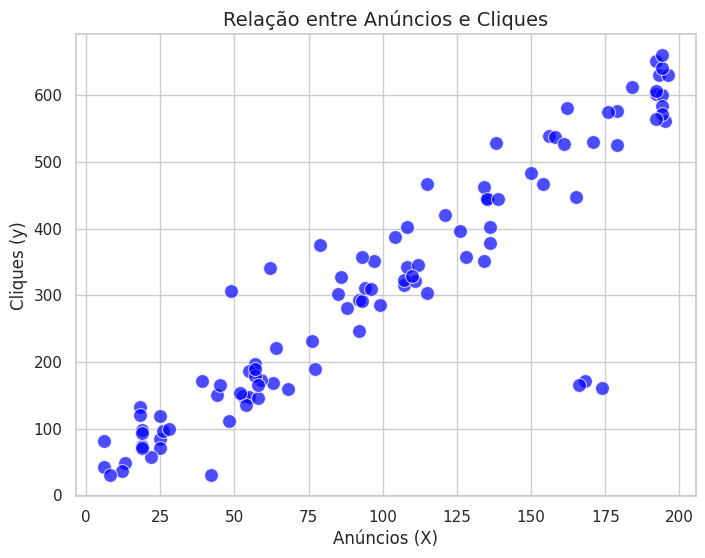

In [2]:
# Carregar os dados
df = pd.read_csv("marketing.csv")

# Exibir as primeiras linhas
display(df.head())

# Informações do dataset
df.info()

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x="anuncios", y="cliques", data=df, color="blue", s=100, alpha=0.7)
plt.title("Relação entre Anúncios e Cliques", fontsize=14)
plt.xlabel("Anúncios (X)", fontsize=12)
plt.ylabel("Cliques (y)", fontsize=12)
plt.show()

## 2. Pré-processamento

In [3]:
X = df[["anuncios"]]
y = df["cliques"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Modelagem

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 4. Validação

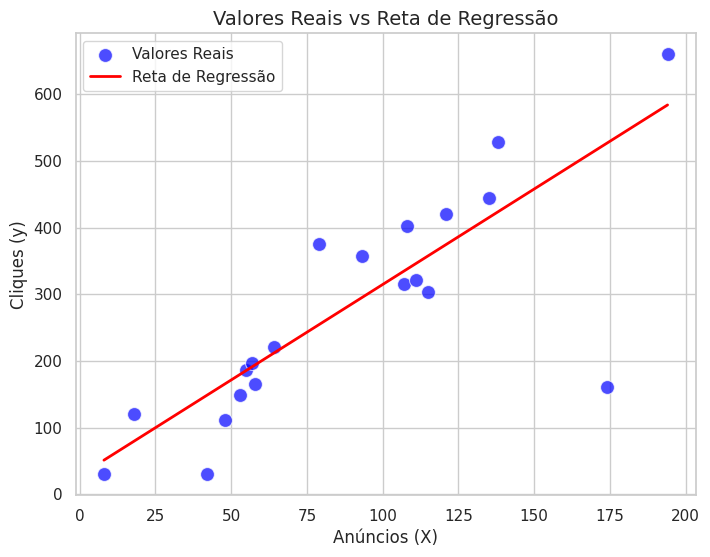

R²: 0.6199
RMSE: 100.2397


In [5]:
y_pred = model.predict(X_test)

# Plotando os dados reais e a reta de regressão
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test["anuncios"], y=y_test, color="blue", label="Valores Reais", s=100, alpha=0.7)
sns.lineplot(x=X_test["anuncios"], y=y_pred, color="red", label="Reta de Regressão", linewidth=2)
plt.title("Valores Reais vs Reta de Regressão", fontsize=14)
plt.xlabel("Anúncios (X)", fontsize=12)
plt.ylabel("Cliques (y)", fontsize=12)
plt.legend()
plt.show()

# Métricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")